## Setup

In [66]:
import os
from collections import defaultdict
import pandas as pd
import numpy as np 
import glob
from pprint import pp

import matplotlib.pyplot as plt
import seaborn as sns


In [67]:

def load_dataset(base_path):
    X, y = [], []
    
    classes = ['frown', 'pucker', 'smile']
    
    for label, cls in enumerate(classes):
        files = glob.glob(os.path.join(base_path, cls, "*.csv"))
        
        for file in files:
            df = pd.read_csv(file)
            X.append(df)
            y.append(label)
    
    return X, y

X_train_raw, y_train = load_dataset("Data 5/train")
X_test_raw, y_test   = load_dataset("Data 5/test")



In [68]:
print(X_train_raw[0],"Label:",y_train[0])

       corrugator supercilii  zygomaticus major  orbicularis oris  \
0                   -577.525           -109.752           485.070   
1                   -580.261           -110.485           485.681   
2                   -579.419           -111.144           487.330   
3                   -577.965           -106.637           484.484   
4                   -577.916           -108.176           485.827   
...                      ...                ...               ...   
10235               -531.572            -84.442           470.620   
10236               -528.396            -85.529           468.470   
10237               -524.903            -82.219           466.735   
10238               -526.918            -85.285           466.918   
10239               -526.552            -84.760           468.885   

       orbicularis oculi  
0               3048.045  
1               3047.020  
2               3049.145  
3               3047.691  
4               3047.960  
...      

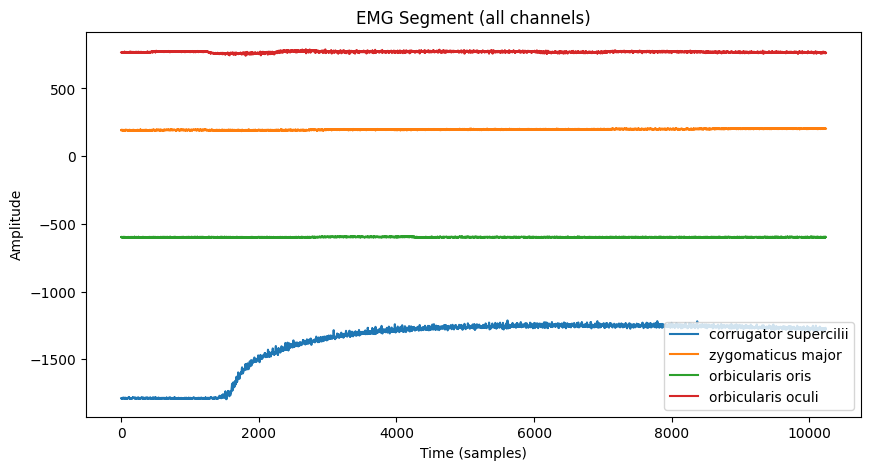

In [69]:
import matplotlib.pyplot as plt

# frown expression
segment = X_train_raw[1]  # one 5-second segment

plt.figure(figsize=(10, 5))

for col in segment.columns:
    plt.plot(segment[col].values, label=col)

plt.title("EMG Segment (all channels)")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

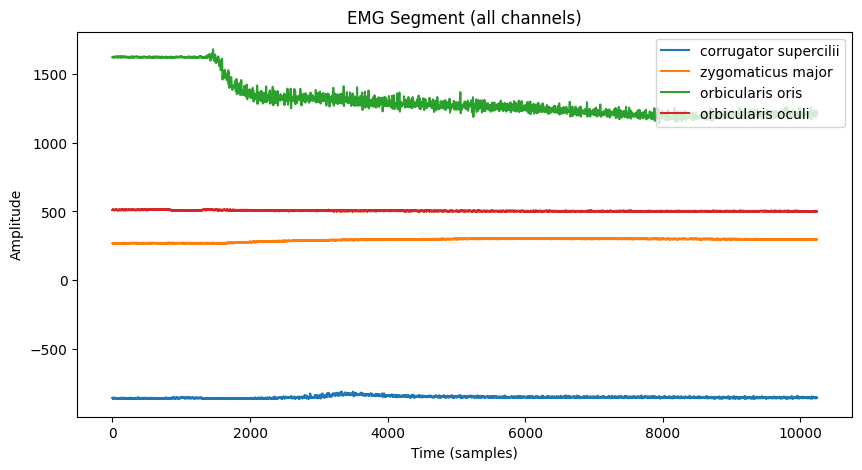

In [70]:
import matplotlib.pyplot as plt

# pucker expression
segment = X_train_raw[221]  # one 5-second segment

plt.figure(figsize=(10, 5))

for col in segment.columns:
    plt.plot(segment[col].values, label=col)

plt.title("EMG Segment (all channels)")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

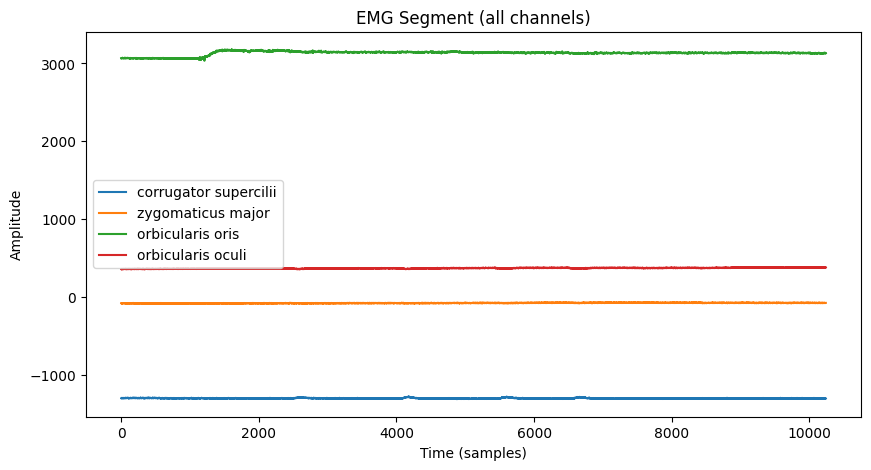

In [71]:
import matplotlib.pyplot as plt

# smile expression
segment = X_train_raw[332]  # one 5-second segment

plt.figure(figsize=(10, 5))

for col in segment.columns:
    plt.plot(segment[col].values, label=col)

plt.title("EMG Segment (all channels)")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

## Processing

In [72]:
from scipy.signal import butter, filtfilt, iirnotch
import numpy as np

def notch_filter(signal, fs=2048, freq=50):
    b, a = iirnotch(freq, 30, fs)
    return filtfilt(b, a, signal)

def bandpass_filter(signal, fs=2048, lowcut=20, highcut=450, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal, axis=0)

def preprocess_df(df):
    processed = df.copy()
    
    for col in df.columns:
        processed[col] = notch_filter(df[col].values)
        processed[col] = bandpass_filter(df[col].values)
    
    return processed

X_train = [preprocess_df(df) for df in X_train_raw]
X_test  = [preprocess_df(df) for df in X_test_raw]

In [73]:
print("Before:", X_train_raw[0].var().values)
print("After:", X_train[0].var().values)

Before: [309.4629828  179.19420448  17.67514181 977.97975352]
After: [14.39210861  3.21975906  9.971283    4.9190348 ]


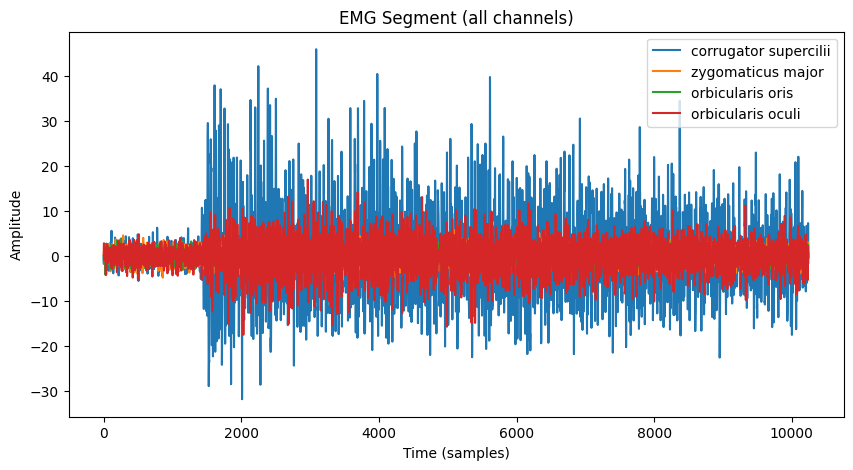

In [74]:
import matplotlib.pyplot as plt

# frown expression
segment = X_train[1]  # one 5-second segment

plt.figure(figsize=(10, 5))

for col in segment.columns:
    plt.plot(segment[col].values, label=col)

plt.title("EMG Segment (all channels)")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

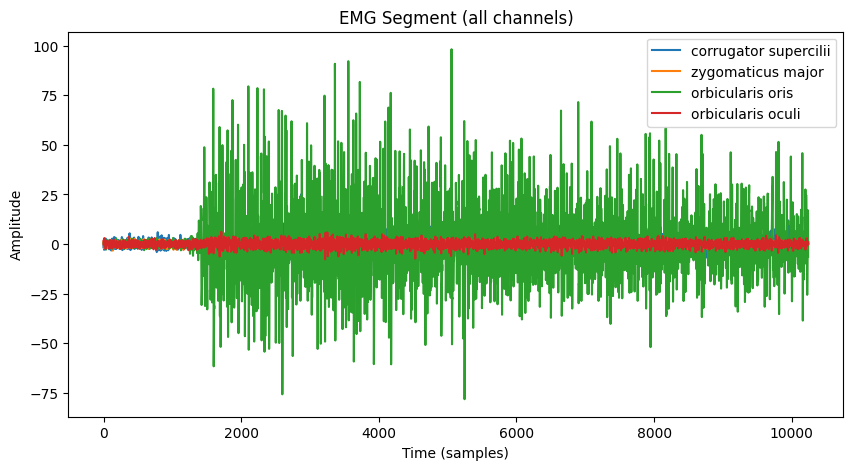

In [75]:
import matplotlib.pyplot as plt

# pucker expression
segment = X_train[221]  # one 5-second segment

plt.figure(figsize=(10, 5))

for col in segment.columns:
    plt.plot(segment[col].values, label=col)

plt.title("EMG Segment (all channels)")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

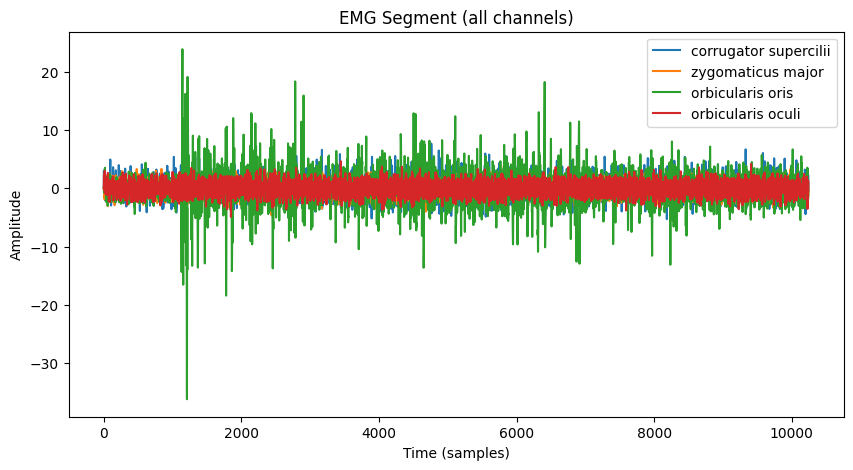

In [76]:
import matplotlib.pyplot as plt

# smile expression
segment = X_train[332]  # one 5-second segment

plt.figure(figsize=(10, 5))

for col in segment.columns:
    plt.plot(segment[col].values, label=col)

plt.title("EMG Segment (all channels)")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

## Feature extraction

- time-domain features
- frequency-domain features

In [77]:
from scipy.signal import welch
import pywt

def time_features(x):
    return [
        np.mean(x),
        np.std(x),
        np.max(np.abs(x)),
        np.sqrt(np.mean(x**2)),  # RMS (very important)
    ]

def waveform_length(x):
    return np.sum(np.abs(np.diff(x)))


def turns_count(x, threshold=0.01):
    diff = np.diff(x)
    turns = np.where((diff[:-1] * diff[1:] < 0) & (np.abs(diff[:-1]) > threshold))[0]
    return len(turns)


def bandpower(x, fs, fmin, fmax):
    freqs, psd = welch(x, fs=fs)
    idx = (freqs >= fmin) & (freqs <= fmax)
    return np.trapezoid(psd[idx], freqs[idx])


def wavelet_energy(x):
    coeffs = pywt.wavedec(x, 'db4', level=3)
    return [np.sum(c**2) for c in coeffs]

def extract_features(df, fs=2048):
    features = []
    
    for col in df.columns:
        x = df[col].values
        
        # Time
        features.extend(time_features(x))
        features.append(waveform_length(x))
        features.append(turns_count(x))
        
        # Frequency
        features.extend([
            bandpower(x, fs, 20, 50),
            bandpower(x, fs, 50, 100),
            bandpower(x, fs, 100, 200),
            bandpower(x, fs, 200, 400),
        ])
        
        # Wavelet
        features.extend(wavelet_energy(x))
    
    return np.array(features)

In [78]:
# Applying the feature extraction on the data

X_train_feat = np.array([extract_features(df) for df in X_train])
X_test_feat  = np.array([extract_features(df) for df in X_test])

print([X_train_feat.shape])

[(360, 56)]


In [80]:
# Normalization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat  = scaler.transform(X_test_feat)

In [81]:
# Just. to check that there is no NaN values

print(np.isnan(X_train).sum())

0


In [82]:
print(X_train_feat.shape)
print(X_test_feat.shape)

(360, 56)
(90, 56)


In [85]:
set(y_train) 

{0, 1, 2}

### Random Forest

In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_feat, y_train)

y_pred = rf.predict(X_test_feat)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        30
           1       0.97      1.00      0.98        30
           2       0.94      1.00      0.97        30

    accuracy                           0.97        90
   macro avg       0.97      0.97      0.97        90
weighted avg       0.97      0.97      0.97        90



In [89]:
print(confusion_matrix(y_test, y_pred))

[[27  1  2]
 [ 0 30  0]
 [ 0  0 30]]


### SVM

In [87]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1, gamma='scale')

svm.fit(X_train_feat, y_train)

y_pred_svm = svm.predict(X_test_feat)

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      0.70      0.82        30
           1       0.82      0.60      0.69        30
           2       0.64      1.00      0.78        30

    accuracy                           0.77        90
   macro avg       0.82      0.77      0.77        90
weighted avg       0.82      0.77      0.77        90



In [90]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    print("\nDetailed classification report:")
    print(classification_report(
        y_test, y_pred,
        target_names=['Frown', 'Pucker', 'Smile']
    ))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Frown', 'Pucker', 'Smile']
    )
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()


=== Random Forest ===
Accuracy:  0.9667
Precision: 0.9684
Recall:    0.9667
F1-Score:  0.9662

Detailed classification report:
              precision    recall  f1-score   support

       Frown       1.00      0.90      0.95        30
      Pucker       0.97      1.00      0.98        30
       Smile       0.94      1.00      0.97        30

    accuracy                           0.97        90
   macro avg       0.97      0.97      0.97        90
weighted avg       0.97      0.97      0.97        90



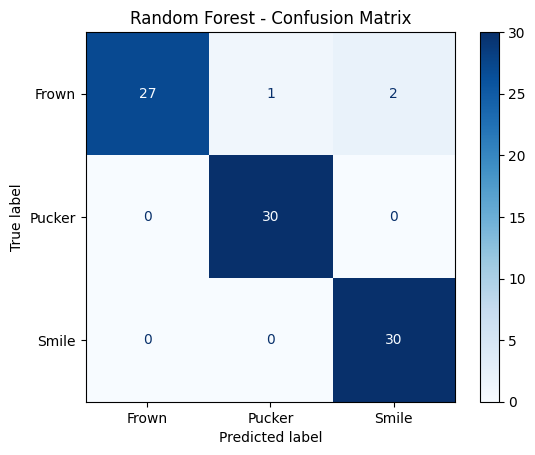


=== SVM ===
Accuracy:  0.7667
Precision: 0.8188
Recall:    0.7667
F1-Score:  0.7650

Detailed classification report:
              precision    recall  f1-score   support

       Frown       1.00      0.70      0.82        30
      Pucker       0.82      0.60      0.69        30
       Smile       0.64      1.00      0.78        30

    accuracy                           0.77        90
   macro avg       0.82      0.77      0.77        90
weighted avg       0.82      0.77      0.77        90



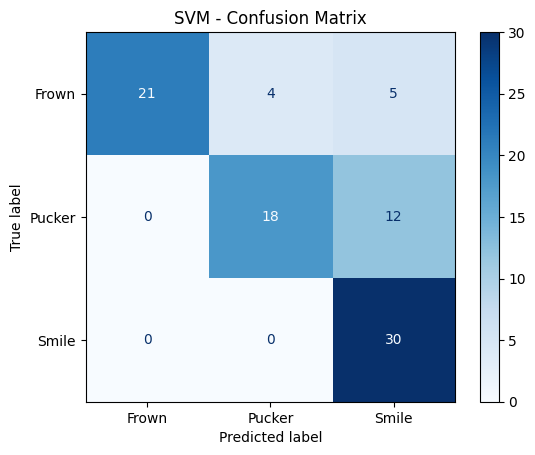

In [91]:
evaluate_model(rf, X_test_feat, y_test, "Random Forest")
evaluate_model(svm, X_test_feat, y_test, "SVM")